In [19]:
import numpy as np
import pandas as pd

df = pd.read_csv('social_contracts.csv')
df['timestamp'] = pd.to_datetime(pd.to_numeric(df['timestamp']), unit='ms', utc=True)
df['day'] = df['timestamp'].dt.floor('D')

df.head()

,player_id,friend,timestamp,day
0,13091,10478,2016-01-27 15:53:20+00:00,2016-01-27 00:00:00+00:00
1,13091,10478,2016-01-30 16:06:40+00:00,2016-01-30 00:00:00+00:00
2,13091,10478,2016-02-01 15:20:00+00:00,2016-02-01 00:00:00+00:00
3,13091,10478,2016-02-04 15:33:20+00:00,2016-02-04 00:00:00+00:00
4,13091,10478,2016-02-07 15:46:40+00:00,2016-02-07 00:00:00+00:00


In [20]:
period_order = ['A', 'B', 'C']

def assign_period(day: pd.Timestamp) -> str:
    if day < pd.Timestamp('2016-02-08', tz='UTC'):
        return 'A'
    if day < pd.Timestamp('2016-03-01', tz='UTC'):
        return 'B'
    return 'C'

df['period'] = df['day'].apply(assign_period)
df['period'] = pd.Categorical(df['period'], categories=period_order, ordered=True)

df.groupby('period', observed=True).size().rename('events').reset_index()

,period,events
0,A,55128
1,B,64017
2,C,152206


In [21]:
incoming = (
    df.groupby(['period', 'player_id'], observed=True)
      .agg(incoming_count=('player_id', 'size'), incoming_days=('day', 'nunique'))
      .reset_index()
      .rename(columns={'player_id': 'player'})
)

outgoing = (
    df.groupby(['period', 'friend'], observed=True)
      .agg(outgoing_count=('friend', 'size'), outgoing_days=('day', 'nunique'))
      .reset_index()
      .rename(columns={'friend': 'player'})
)

stats = pd.merge(incoming, outgoing, on=['period', 'player'], how='outer')
count_cols = ['incoming_count', 'incoming_days', 'outgoing_count', 'outgoing_days']
stats[count_cols] = stats[count_cols].fillna(0).astype(int)

senders = stats[stats['outgoing_count'] > 0].copy()
senders['io_ratio'] = senders['incoming_count'] / senders['outgoing_count']
senders['io_days_ratio'] = senders['incoming_days'] / senders['outgoing_days']
senders['low_count_receiver'] = senders['io_ratio'] < 0.5
senders['zero_count_receiver'] = senders['incoming_count'] == 0

min_regular_outgoing_days = 2 # adjustable
regular_senders = senders[senders['outgoing_days'] >= min_regular_outgoing_days].copy()
#regular_senders['low_day_receiver'] = regular_senders['io_days_ratio'] < 0.5
regular_senders['low_day_receiver'] = (regular_senders['io_days_ratio'] < 0.8) & (regular_senders['io_ratio'] < 0.8) # adjustable
regular_senders['zero_day_receiver'] = regular_senders['incoming_days'] == 0

regular_senders.head()

,period,player,incoming_count,incoming_days,outgoing_count,outgoing_days,io_ratio,io_days_ratio,low_count_receiver,zero_count_receiver,low_day_receiver,zero_day_receiver
0,A,101,159,15,19,16,8.368421,0.937500,False,False,False,False
1,A,102,16,9,16,14,1.000000,0.642857,False,False,False,False
2,A,104,4,3,15,13,0.266667,0.230769,True,False,True,False
3,A,110,2,1,3,3,0.666667,0.333333,False,False,True,False
4,A,113,5,4,15,10,0.333333,0.400000,True,False,True,False


In [22]:
# testing edge-cases
regular_senders[(regular_senders['io_days_ratio'] < .5) & (regular_senders['io_ratio'] > 1)]

,period,player,incoming_count,incoming_days,outgoing_count,outgoing_days,io_ratio,io_days_ratio,low_count_receiver,zero_count_receiver,low_day_receiver,zero_day_receiver
1324,A,14615,12,2,7,5,1.714286,0.400000,False,False,False,False
5170,A,77467,4,1,3,3,1.333333,0.333333,False,False,False,False
6235,A,100506,7,1,4,4,1.750000,0.250000,False,False,False,False
8098,A,135741,12,1,5,4,2.400000,0.250000,False,False,False,False
12340,A,193340,4,1,3,3,1.333333,0.333333,False,False,False,False
17525,B,60374,20,1,3,3,6.666667,0.333333,False,False,False,False
21736,B,138664,4,1,3,3,1.333333,0.333333,False,False,False,False
21972,B,142318,13,3,7,7,1.857143,0.428571,False,False,False,False
24898,B,179832,16,3,12,10,1.333333,0.300000,False,False,False,False
28649,B,212216,10,3,8,8,1.250000,0.375000,False,False,False,False


In [23]:
bayes_summary = (
    regular_senders
    .groupby('period', observed=True)
    .agg(
        n=('player', 'count'),
        k=('low_day_receiver', 'sum'),
        observed_rate=('low_day_receiver', 'mean')
    )
    .reindex(period_order)
)

bayes_summary['observed_rate_pct'] = bayes_summary['observed_rate'] * 100

bayes_summary

,n,k,observed_rate,observed_rate_pct
period,,,,
A,6319,4080,0.645672,64.567178
B,7824,5070,0.648006,64.800613
C,13778,5834,0.423429,42.342865


In [24]:
# Prior parameters
prior_alpha = 1
prior_beta = 1

# Posterior parameters for each period
bayes_summary['posterior_alpha'] = prior_alpha + bayes_summary['k']
bayes_summary['posterior_beta'] = prior_beta + bayes_summary['n'] - bayes_summary['k']

bayes_summary

,n,k,observed_rate,observed_rate_pct,posterior_alpha,posterior_beta
period,,,,,,
A,6319,4080,0.645672,64.567178,4081,2240
B,7824,5070,0.648006,64.800613,5071,2755
C,13778,5834,0.423429,42.342865,5835,7945


In [25]:
rng = np.random.default_rng(42)

n_samples = 100_000

posterior_samples = {}

for period in period_order:
    alpha = bayes_summary.loc[period, 'posterior_alpha']
    beta = bayes_summary.loc[period, 'posterior_beta']
    posterior_samples[period] = rng.beta(alpha, beta, size=n_samples)

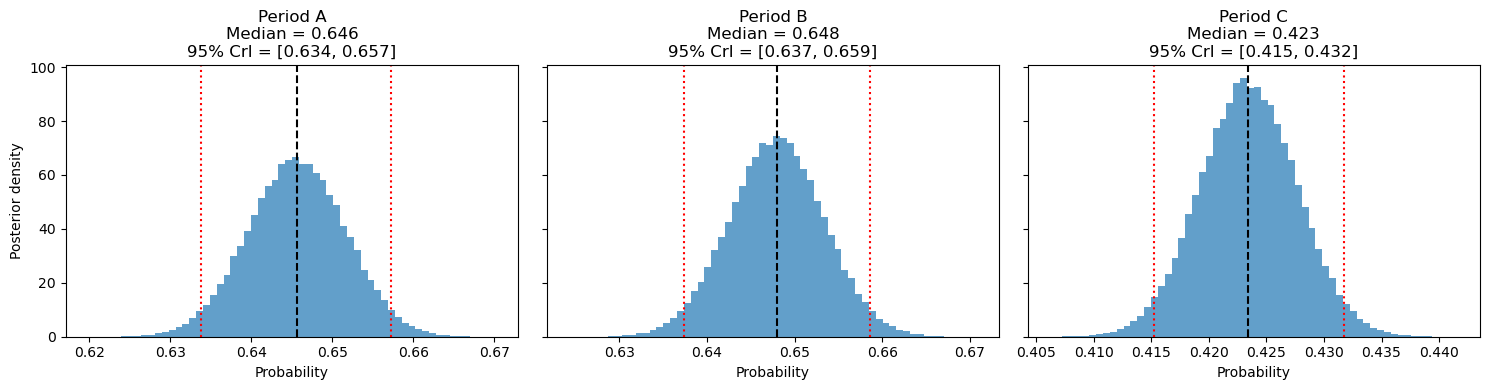

In [26]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, period in zip(axes, period_order):
    samples = posterior_samples[period]
    lower, median, upper = np.quantile(samples, [0.025, 0.5, 0.975])

    ax.hist(samples, bins=60, density=True, alpha=0.7)
    ax.axvline(median, color='black', linestyle='--')
    ax.axvline(lower, color='red', linestyle=':')
    ax.axvline(upper, color='red', linestyle=':')

    ax.set_title(
        f'Period {period}\n'
        f'Median = {median:.3f}\n'
        f'95% CrI = [{lower:.3f}, {upper:.3f}]'
    )
    ax.set_xlabel('Probability')

axes[0].set_ylabel('Posterior density')
plt.tight_layout()
plt.show()

In [27]:
p_A = posterior_samples['A']
p_B = posterior_samples['B']
p_C = posterior_samples['C']

prob_B_better_than_A = np.mean(p_B < p_A)
prob_C_better_than_A = np.mean(p_C < p_A)
prob_C_better_than_B = np.mean(p_C < p_B)

comparison_probs = pd.DataFrame({
    'comparison': [
        'B lower than A',
        'C lower than A',
        'C lower than B',
    ],
    'posterior_probability': [
        prob_B_better_than_A,
        prob_C_better_than_A,
        prob_C_better_than_B,
    ]
})

comparison_probs

,comparison,posterior_probability
0,B lower than A,0.38739
1,C lower than A,1.00000
2,C lower than B,1.00000
